In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    
    for k in range(max_iterations):
        x_new = x.copy()
        
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
         
        err = np.linalg.norm(x_new - x, ord=np.inf) #Records error and puts in a list
        errors.append(err)
        if err < tol:  #Checks convergence
            return x_new, k, errors
        x = x_new
    return x, max_iterations, errors


In [3]:
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    
    for k in range(max_iterations): #Jocobi algorithm
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i] 
        
        # Check for convergence
        err = np.linalg.norm(x_new - x, ord=np.inf) #Records errors
        errors.append(err)
        if err < tol:
            return x_new, k, errors
        x = x_new
    return x, max_iterations, errors


Regular Solve:  [ 3.  -2.5  7. ]

Tolerance = 0.001

Jacobi Solution: [ 3.0000225  -2.50000266  6.99998104]
Iterations: 3
Elapsed Time:  0.00038854964077472687
Gauss-Seidel Solution: [ 3.00000035 -2.50000004  6.99999999]
Iterations: 3
Elapsed Time:  0.0002890676259994507


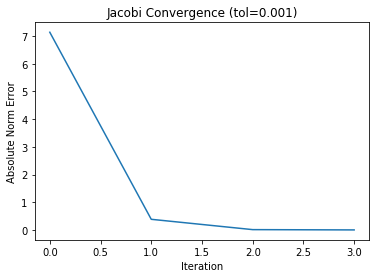

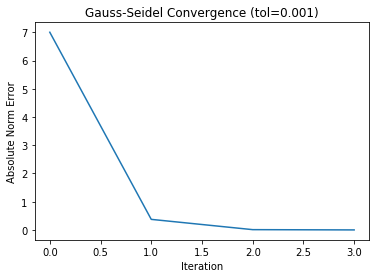


Tolerance = 1e-06

Jacobi Solution: [ 3.  -2.5  7. ]
Iterations: 6
Elapsed Time:  0.0003880355507135391
Gauss-Seidel Solution: [ 3.  -2.5  7. ]
Iterations: 4
Elapsed Time:  0.00021018274128437042


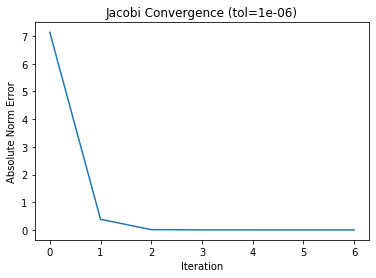

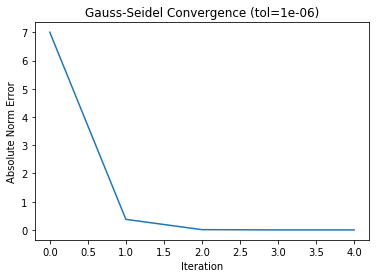


Tolerance = 1e-09

Jacobi Solution: [ 3.  -2.5  7. ]
Iterations: 8
Elapsed Time:  0.0009187478572130203
Gauss-Seidel Solution: [ 3.  -2.5  7. ]
Iterations: 6
Elapsed Time:  0.0007711863145232201


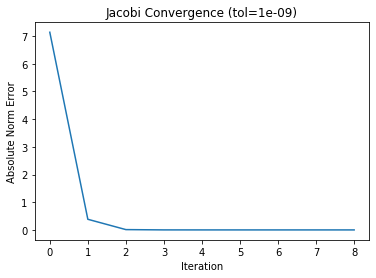

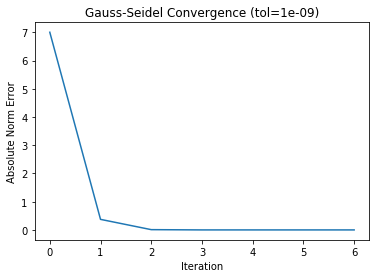

In [4]:
A = np.array([[3,-0.1,-0.2],
               [0.1,7,-0.3],
               [0.3,-0.2,10]], dtype=float)
b = np.array([7.85,-19.3,71.4], dtype=float)
x0 = np.zeros(3)

x = np.linalg.solve(A,b) 

print("Regular Solve: ", x) #Sanity Check

max_iterations = 10000

tolerances = [1e-3,1e-6,1e-9]

for tol in tolerances: #Runs through tolerances
    print(f"\nTolerance = {tol}")
    
       
    #Performs Jacobi algo and records total time and error between iteration
    start_time = time.perf_counter()
    solution_J, iterations_J, errors_J = jacobi(A, b, x0, tol, max_iterations)
    end_time = time.perf_counter()
    elapsed_time_J = end_time - start_time
    print(f"\nJacobi Solution: {solution_J}")
    print(f"Iterations: {iterations_J}")
    print("Elapsed Time: " , elapsed_time_J)
    
    #Performs Gauss-Seidel algo and records total time and error between iteration
    start_time = time.perf_counter()
    solution_GS, iterations_GS, errors_GS = gauss_seidel(A, b, x0, tol, max_iterations)
    end_time = time.perf_counter()
    elapsed_time_GS = end_time - start_time
    print(f"Gauss-Seidel Solution: {solution_GS}")
    print(f"Iterations: {iterations_GS}")
    print("Elapsed Time: " , elapsed_time_GS)
    
    
    # Plot Jacobi error
    plt.figure()
    plt.plot(errors_J)
    plt.title(f"Jacobi Convergence (tol={tol})")
    plt.xlabel("Iteration")
    plt.ylabel("Absolute Norm Error")
    plt.show()
    
    # Plot Gauss-Seidel error
    plt.figure()
    plt.plot(errors_GS)
    plt.title(f"Gauss-Seidel Convergence (tol={tol})")
    plt.xlabel("Iteration")
    plt.ylabel("Absolute Norm Error")
    plt.show()

Notice that the matrix is diagonally dominant, so both methods converge. While Gauss-Seidel took less iterations to converge than Jacobi in general, Jacobi was faster. Smaller tolerance implies that more iterations were required. Plots show that absolute error dropped rapidly after the first few iterations.